In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

The Following is constant for all studies:

Time Simulated

Time Step

Total Fiber length

Fibers are simulated using UNLIGATED material properties

Length change is measured through the change in tip position

In [2]:
l0 = 10e-6; #[m]
lm = 36.9356e-06 #[m]
dx = .5e-6; #[m]
l0_LB = l0/dx;
LB_Offset = 10;
lm_LB = lm/dx;
tau=1; #0.95; # best accuracy
vis=1e-3; #[pa*s]
rho=1e3; #[kg/m^3]
dt=(tau-0.5)/3*dx**2*rho/vis;
dm = rho*dx*dx*dx; # water mass
kBT=1.3806e-23*296; # thermal energy

#To Convert Forces to lb Units
# Force_LB = Force*dt**2/dm/dx;
# Forces in LB units kept to 0.xxxx 

In [3]:
Force = 2.5e-9;

Force_LB = Force*dt**2/dm/dx;

print(Force_LB)

0.0694444444444444


In [4]:
#Unligated Fibers
def f_l_Pow(l,A,l_m,k_p):
    return A*((1/4)*(1-(l/l_m))**(-2)-(1/4)+(l/l_m)) - (k_p/(l**2))
def f_x_Pow(x,A,l_m,k_p):
    return A*((1/4)*(1-(x))**(-2)-(1/4)+(x)) - (k_p/((x*l_m)**2))
def f_s_Pow(s,A,l_m,k_p):
    return A*((1/4)*(1-((s*l0+l0)/l_m))**(-2)-(1/4)+((s*l0)/l_m)) - (k_p/((s*l0+l0)**2))
       
Len_Data = np.array([[0.000010305810397553517, 1.8106213172223922e-10],
[0.000010672782874617739, 2.39800104423072e-10],
[0.000011039755351681958, 4.204892966360933e-10],
[0.000011498470948012234, 6.006190795852975e-10],
[0.000012048929663608564, 5.972626240023954e-10],
[0.000012660550458715597, 8.374356679346656e-10],
[0.00001327217125382263, 1.0776087118669423e-9],
[0.000013944954128440366, 1.378384426046102e-9],
[0.000014678899082568809, 1.739762810472151e-9],
[0.000015412844036697248, 2.101141194898187e-9],
[0.00001617737003058104, 2.4013574998135296e-9],
[0.000016972477064220186, 2.7623629447303674e-9],
[0.00001779816513761468, 3.184157529648697e-9],
[0.000018623853211009176, 3.544976504810926e-9],
[0.000019480122324159025, 3.966584619974643e-9],
[0.000020366972477064223, 4.388006265383755e-9],
[0.000021223241590214068, 4.931565600059671e-9],
[0.00002214067278287462, 5.4747519952263785e-9],
[0.000022996941896024468, 6.262213768926681e-9],
[0.00002391437308868502, 7.049302603117779e-9],
[0.000024831804281345567, 8.202245095845456e-9],
[0.000025779816513761472, 9.84280599686731e-9],
[0.000026697247706422023, 1.1971358245692547e-8],
[0.000027614678899082575, 1.4465764153054376e-8],
[0.000028562691131498476, 1.7874617737003056e-8],
[0.000029480122324159024, 2.189341388826732e-8],
[0.000030397553516819575, 2.670489296636085e-8]])

Len_Data_Fit = Len_Data*(1e+9); #Increasing the magnitude of the data for the curve fitter (Helps with error)
alpha_Pow = optimize.curve_fit(f_l_Pow, xdata = Len_Data_Fit[:,0] , ydata = Len_Data_Fit[:,1],p0 = [3,4e+4,1e+7])[0]; # Fit curve using least squares method

print('Unligated Parameters:')
A = alpha_Pow[0]*1e-9,
print('A = '+str(alpha_Pow[0]*1e-9))
l_m = alpha_Pow[1]*1e-9,
print('lm = '+str(alpha_Pow[1]*1e-9))
k_p = alpha_Pow[2]*1e-27,
print('kp = '+str(alpha_Pow[2]*1e-27))

#Define the function in terms of force vs x = l/lm
x_vect = Len_Data[:,0]/l_m;
x_data = np.vstack((x_vect,Len_Data[:,1]))

#Define the function in terms of force vs strain
Exp_Strain = np.zeros(np.size(Len_Data[:,0]));
for i in range(0,np.size(Len_Data[:,0]),1):
    Exp_Strain[i] = (Len_Data[i,0]-l0)/l0;


Unligated Parameters:
A = 3.2265438863137044e-09
lm = 3.693568656134975e-05
kp = 1.8696547567965926e-19


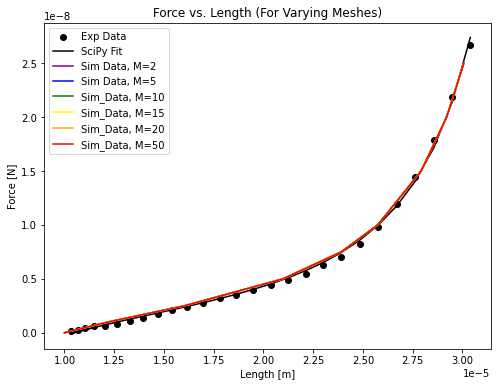

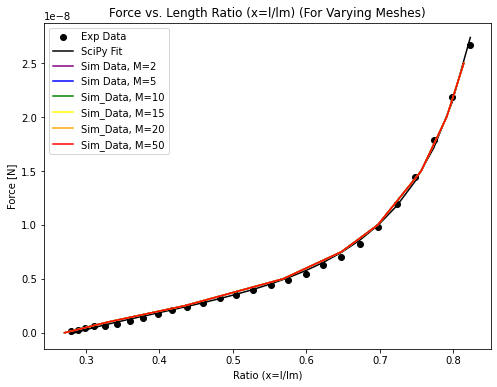

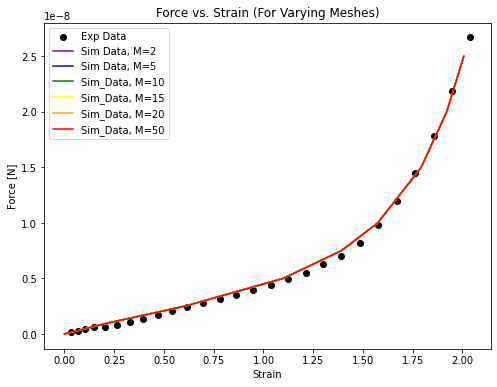

0.22073499999999996   1e-09
0.6034149999999997   2.5e-09
1.0987649999999995   5e-09
1.3913249999999995   7.5e-09
1.5745399999999994   1e-08
1.7926799999999996   1.5e-08
1.9207899999999998   2e-08
2.0069049999999993   2.5e-08


In [18]:
# Combined Results
#Initial Tip Postion: z = 30 [lb units]
#Raw Format: [Position [lb Units], Force [lb Units], Force [N]]
M_2_Raw = np.array([
    [30,0,0],
    [34.4147,.0277,1e-9],
    [42.0683,.0694,2.5e-9],
    [51.9754,.1388,5e-9],
    [57.8265,.2083,7.5e-9],
    [61.4909,.2777,10e-9],
    [65.8537,.4166,15e-9],
    [68.4158,.5555,20e-9],
    [70.1381,.6944,25e-9],
]);
M_2_Strain = np.zeros(np.size(M_2_Raw[:,0]));
M_2_Len = np.zeros(np.size(M_2_Raw[:,0]));
M_2_Ratio = np.zeros(np.size(M_2_Raw[:,0]));
for i in range(0,np.size(M_2_Raw[:,0]),1):
    M_2_Strain[i] = (M_2_Raw[i,0]-l0_LB-LB_Offset)/l0_LB;
    M_2_Len[i] = M_2_Strain[i]*l0_LB*dx + l0;
    M_2_Ratio[i] = M_2_Len[i]/lm;
    
M_5_Raw = np.array([
    [30,0,0],
    [34.4144,.0277,1e-9],
    [42.0683,.0694,2.5e-9],
    [51.9753,.1388,5e-9],
    [57.8265,.2083,7.5e-9],
    [61.4909,.2777,10e-9],
    [65.8537,.4166,15e-9],
    [68.4158,.5555,20e-9],
    [70.1381,.6944,25e-9],
]);
M_5_Strain = np.zeros(np.size(M_5_Raw[:,0]));
M_5_Len = np.zeros(np.size(M_5_Raw[:,0]));
M_5_Ratio = np.zeros(np.size(M_5_Raw[:,0]));
for i in range(0,np.size(M_5_Raw[:,0]),1):
    M_5_Strain[i] = (M_5_Raw[i,0]-l0_LB-LB_Offset)/l0_LB;
    M_5_Len[i] = M_5_Strain[i]*l0_LB*dx + l0;
    M_5_Ratio[i] = M_5_Len[i]/lm;
    
M_10_Raw = np.array([
    [30,0,0],
    [34.3885,.0277,1e-9],
    [42.0683,.0694,2.5e-9],
    [51.9624,.1388,5e-9],
    [57.8264,.2083,7.5e-9],
    [61.4908,.2777,10e-9],
    [65.8536,.4166,15e-9],
    [68.4158,.5555,20e-9],
    [70.1381,.6944,25e-9],
]);
M_10_Strain = np.zeros(np.size(M_10_Raw[:,0]));
M_10_Len = np.zeros(np.size(M_10_Raw[:,0]));
M_10_Ratio = np.zeros(np.size(M_10_Raw[:,0]));
for i in range(0,np.size(M_10_Raw[:,0]),1):
    M_10_Strain[i] = (M_10_Raw[i,0]-l0_LB-LB_Offset)/l0_LB;
    M_10_Len[i] = M_10_Strain[i]*l0_LB*dx + l0;
    M_10_Ratio[i] = M_10_Len[i]/lm;
    
M_15_Raw = np.array([
    [30,0,0],
    [34.4147,.0277,1e-9],
    [42.0683,.0694,2.5e-9],
    [51.9753,.1388,5e-9],
    [57.8264,.2083,7.5e-9],
    [61.4908,.2777,10e-9],
    [65.8536,.4166,15e-9],
    [68.4158,.5555,20e-9],
    [70.1381,.6944,25e-9],
]);
M_15_Strain = np.zeros(np.size(M_15_Raw[:,0]));
M_15_Len = np.zeros(np.size(M_15_Raw[:,0]));
M_15_Ratio = np.zeros(np.size(M_15_Raw[:,0]));
for i in range(0,np.size(M_15_Raw[:,0]),1):
    M_15_Strain[i] = (M_15_Raw[i,0]-l0_LB-LB_Offset)/l0_LB;
    M_15_Len[i] = M_15_Strain[i]*l0_LB*dx + l0;
    M_15_Ratio[i] = M_15_Len[i]/lm;
    
M_20_Raw = np.array([
    [30,0,0],
    [34.4146,.0277,1e-9],
    [42.0683,.0694,2.5e-9],
    [51.9753,.1388,5e-9],
    [57.8264,.2083,7.5e-9],
    [61.4908,.2777,10e-9],
    [65.8536,.4166,15e-9],
    [68.4157,.5555,20e-9],
    [70.1380,.6944,25e-9],
]);
M_20_Strain = np.zeros(np.size(M_20_Raw[:,0]));
M_20_Len = np.zeros(np.size(M_20_Raw[:,0]));
M_20_Ratio = np.zeros(np.size(M_20_Raw[:,0]));
for i in range(0,np.size(M_20_Raw[:,0]),1):
    M_20_Strain[i] = (M_20_Raw[i,0]-l0_LB-LB_Offset)/l0_LB;
    M_20_Len[i] = M_20_Strain[i]*l0_LB*dx + l0;
    M_20_Ratio[i] = M_20_Len[i]/lm;
M_50_Raw = np.array([
    [30,0,0],
    [34.4147,.0277,1e-9],
    [42.0683,.0694,2.5e-9],
    [51.9753,.1388,5e-9],
    [57.8265,.2083,7.5e-9],
    [61.4908,.2777,10e-9],
    [65.8536,.4166,15e-9],
    [68.4158,.5555,20e-9],
    [70.1381,.6944,25e-9],
]);
M_50_Strain = np.zeros(np.size(M_50_Raw[:,0]));
M_50_Len = np.zeros(np.size(M_50_Raw[:,0]));
M_50_Ratio = np.zeros(np.size(M_50_Raw[:,0]));
for i in range(0,np.size(M_50_Raw[:,0]),1):
    M_50_Strain[i] = (M_50_Raw[i,0]-l0_LB-LB_Offset)/l0_LB;
    M_50_Len[i] = M_50_Strain[i]*l0_LB*dx + l0;
    M_50_Ratio[i] = M_50_Len[i]/lm;


force_Len,axl = plt.subplots(1,1,figsize=(8,6))                          #plot the curve and the experimental data
plt.title("Force vs. Length (For Varying Meshes)")
axl.set_xlabel("Length [m]")
axl.set_ylabel("Force [N]")
plt.scatter(Len_Data[:,0],Len_Data[:,1],color = 'black',label = 'Exp Data')
plt.plot(Len_Data[:,0], f_l_Pow(Len_Data[:,0],alpha_Pow[0]*1e-9,alpha_Pow[1]*1e-9,alpha_Pow[2]*1e-27),color = 'black',label='SciPy Fit') #Correct the magnitudes of the parameters
plt.plot(M_2_Len,M_2_Raw[:,2],color = 'purple',label = 'Sim Data, M=2')
plt.plot(M_5_Len,M_5_Raw[:,2],color = 'blue',label = 'Sim Data, M=5')
plt.plot(M_10_Len,M_10_Raw[:,2],color = 'green',label = 'Sim_Data, M=10')
plt.plot(M_15_Len,M_15_Raw[:,2],color = 'yellow',label = 'Sim_Data, M=15')
plt.plot(M_20_Len,M_20_Raw[:,2],color = 'orange',label = 'Sim_Data, M=20')
plt.plot(M_50_Len,M_50_Raw[:,2],color = 'red',label = 'Sim_Data, M=50')
axl.legend()
plt.show()

force_Ratio,axr = plt.subplots(1,1,figsize=(8,6))                          #plot the curve and the experimental data
plt.title("Force vs. Length Ratio (x=l/lm) (For Varying Meshes)")
axr.set_xlabel("Ratio (x=l/lm)")
axr.set_ylabel("Force [N]")
plt.scatter(x_data[:][0],Len_Data[:,1],color = 'black',label = 'Exp Data')
plt.plot(x_data[:][0], f_x_Pow(x_data[:][0],A,l_m,k_p),color = 'black',label='SciPy Fit') 
plt.plot(M_2_Ratio,M_2_Raw[:,2],color = 'purple',label = 'Sim Data, M=2')
plt.plot(M_5_Ratio,M_5_Raw[:,2],color = 'blue',label = 'Sim Data, M=5')
plt.plot(M_10_Ratio,M_10_Raw[:,2],color = 'green',label = 'Sim_Data, M=10')
plt.plot(M_15_Ratio,M_15_Raw[:,2],color = 'yellow',label = 'Sim_Data, M=15')
plt.plot(M_20_Ratio,M_20_Raw[:,2],color = 'orange',label = 'Sim_Data, M=20')
plt.plot(M_50_Ratio,M_50_Raw[:,2],color = 'red',label = 'Sim_Data, M=50')
axr.legend()
plt.show()

force_Strain,axs = plt.subplots(1,1,figsize=(8,6))                          #plot the curve and the experimental data
plt.title("Force vs. Strain (For Varying Meshes)")
axs.set_xlabel("Strain")
axs.set_ylabel("Force [N]")
plt.scatter(Exp_Strain,Len_Data[:,1],color = 'black',label = 'Exp Data')
#plt.plot(Exp_Strain, f_s_Pow(Exp_Strain,A,l_m,k_p),color = 'black',label='SciPy Fit') 
plt.plot(M_2_Strain,M_2_Raw[:,2],color = 'purple',label = 'Sim Data, M=2')
plt.plot(M_5_Strain,M_5_Raw[:,2],color = 'blue',label = 'Sim Data, M=5')
plt.plot(M_10_Strain,M_10_Raw[:,2],color = 'green',label = 'Sim_Data, M=10')
plt.plot(M_15_Strain,M_15_Raw[:,2],color = 'yellow',label = 'Sim_Data, M=15')
plt.plot(M_20_Strain,M_20_Raw[:,2],color = 'orange',label = 'Sim_Data, M=20')
plt.plot(M_50_Strain,M_50_Raw[:,2],color = 'red',label = 'Sim_Data, M=50')
axs.legend()
plt.show()

for i in range(1,len(M_2_Strain),1):
    stress =M_50_Strain[i];
    strain = M_50_Raw[i,2];
    print(str(stress),' ',str(strain))

-1.77635683940025e-16
0.2207199999999998
0.6034149999999997
1.0987649999999995
1.3913249999999995
1.5745449999999996
1.7926849999999999
1.9207899999999998
2.0069049999999993


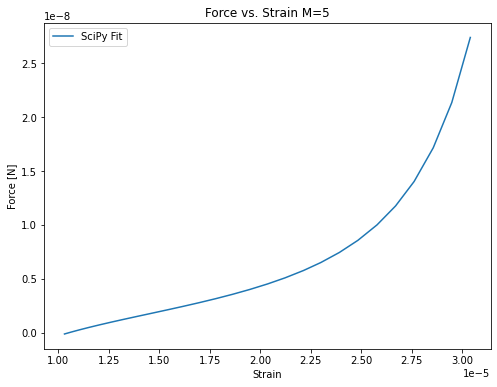

In [6]:
# For M = 5:
#Initial Tip Postion: z = 30 [lb units]
#Raw Format: [Position [lb Units], Force [lb Units], Force [N]]
M_5_Raw = np.array([
    [30,0,0],
    [34.4144,.0277,1e-9],
    [42.0683,.0694,2.5e-9],
    [51.9753,.1388,5e-9],
    [57.8265,.2083,7.5e-9],
    [61.4909,.2777,10e-9],
    [65.8537,.4166,15e-9],
    [68.4158,.5555,20e-9],
    [70.1381,.6944,25e-9],
]);

M_5_Strain = M_5_Raw;
for i in range(0,np.size(M_5_Raw[:,0]),1):
    M_5_Strain[i,0] = (M_5_Raw[i,0]-l0_LB-LB_Offset)/l0_LB;
    print(M_5_Strain[i,0])

force_strain,ax = plt.subplots(1,1,figsize=(8,6))                          #plot the curve and the experimental data
plt.title("Force vs. Strain M=5")
ax.set_xlabel("Strain")
ax.set_ylabel("Force [N]")
#plt.scatter(M_5_Strain[:,0],M_5_Strain[:,2],color = 'black',label = 'Simulation Data')
plt.plot(Len_Data[:,0], f_l_Pow(Len_Data[:,0],alpha_Pow[0]*1e-9,alpha_Pow[1]*1e-9,alpha_Pow[2]*1e-27),label='SciPy Fit') #Correct the magnitudes of the parameters
ax.legend()
plt.show()

-1.77635683940025e-16
0.21942499999999981
0.6034149999999997
1.0981199999999998
1.3913199999999994
1.5745399999999994
1.7926799999999996
1.9207899999999998
2.0069049999999993


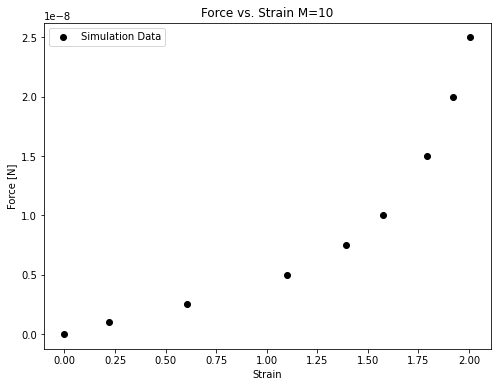

In [7]:
# For M = 10:
#Initial Tip Postion: z = 30 [lb units]
#Raw Format: [Position [lb Units], Force [lb Units], Force [N]]
M_10_Raw = np.array([
    [30,0,0],
    [34.3885,.0277,1e-9],
    [42.0683,.0694,2.5e-9],
    [51.9624,.1388,5e-9],
    [57.8264,.2083,7.5e-9],
    [61.4908,.2777,10e-9],
    [65.8536,.4166,15e-9],
    [68.4158,.5555,20e-9],
    [70.1381,.6944,25e-9],
]);

M_10_Strain = M_10_Raw;
for i in range(0,np.size(M_10_Raw[:,0]),1):
    M_10_Strain[i,0] = (M_10_Raw[i,0]-l0_LB-LB_Offset)/l0_LB;
    print(M_10_Strain[i,0])

force_strain,ax = plt.subplots(1,1,figsize=(8,6))                          #plot the curve and the experimental data
plt.title("Force vs. Strain M=10")
ax.set_xlabel("Strain")
ax.set_ylabel("Force [N]")
plt.scatter(M_10_Strain[:,0],M_10_Strain[:,2],color = 'black',label = 'Simulation Data')
#plt.plot(Len_Data[:,0], f_l_Pow(Len_Data[:,0],alpha_Pow[0]*1e-9,alpha_Pow[1]*1e-9,alpha_Pow[2]*1e-27),label='SciPy Fit') #Correct the magnitudes of the parameters
ax.legend()
plt.show()

-1.77635683940025e-16
0.22073499999999996
0.6034149999999997
1.0987649999999995
1.3913199999999994
1.5745399999999994
1.7926799999999996
1.9207899999999998
2.0069049999999993


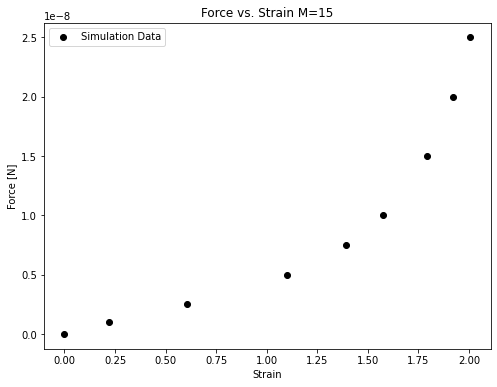

In [8]:
# For M = 15:
#Initial Tip Postion: z = 30 [lb units]
#Raw Format: [Position [lb Units], Force [lb Units], Force [N]]
M_15_Raw = np.array([
    [30,0,0],
    [34.4147,.0277,1e-9],
    [42.0683,.0694,2.5e-9],
    [51.9753,.1388,5e-9],
    [57.8264,.2083,7.5e-9],
    [61.4908,.2777,10e-9],
    [65.8536,.4166,15e-9],
    [68.4158,.5555,20e-9],
    [70.1381,.6944,25e-9],
]);

M_15_Strain = M_15_Raw;
for i in range(0,np.size(M_15_Raw[:,0]),1):
    M_15_Strain[i,0] = (M_15_Raw[i,0]-l0_LB-LB_Offset)/l0_LB;
    print(M_15_Strain[i,0])

force_strain,ax = plt.subplots(1,1,figsize=(8,6))                          #plot the curve and the experimental data
plt.title("Force vs. Strain M=15")
ax.set_xlabel("Strain")
ax.set_ylabel("Force [N]")
plt.scatter(M_15_Strain[:,0],M_15_Strain[:,2],color = 'black',label = 'Simulation Data')
#plt.plot(Len_Data[:,0], f_l_Pow(Len_Data[:,0],alpha_Pow[0]*1e-9,alpha_Pow[1]*1e-9,alpha_Pow[2]*1e-27),label='SciPy Fit') #Correct the magnitudes of the parameters
ax.legend()
plt.show()

-1.77635683940025e-16
0.2207299999999998
0.6034149999999997
1.0987649999999995
1.3913199999999994
1.5745399999999994
1.7926799999999996
1.9207849999999997
2.0069


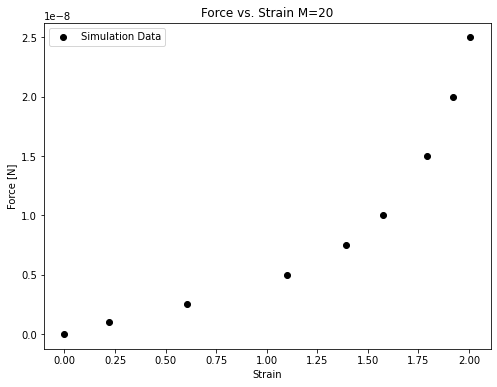

In [9]:
# For M = 20:
#Initial Tip Postion: z = 30 [lb units]
#Raw Format: [Position [lb Units], Force [lb Units], Force [N]]
M_20_Raw = np.array([
    [30,0,0],
    [34.4146,.0277,1e-9],
    [42.0683,.0694,2.5e-9],
    [51.9753,.1388,5e-9],
    [57.8264,.2083,7.5e-9],
    [61.4908,.2777,10e-9],
    [65.8536,.4166,15e-9],
    [68.4157,.5555,20e-9],
    [70.1380,.6944,25e-9],
]);

M_20_Strain = M_20_Raw;
for i in range(0,np.size(M_20_Raw[:,0]),1):
    M_20_Strain[i,0] = (M_20_Raw[i,0]-l0_LB-LB_Offset)/l0_LB;
    print(M_20_Strain[i,0])

force_strain,ax = plt.subplots(1,1,figsize=(8,6))                          #plot the curve and the experimental data
plt.title("Force vs. Strain M=20")
ax.set_xlabel("Strain")
ax.set_ylabel("Force [N]")
plt.scatter(M_20_Strain[:,0],M_20_Strain[:,2],color = 'black',label = 'Simulation Data')
#plt.plot(Len_Data[:,0], f_l_Pow(Len_Data[:,0],alpha_Pow[0]*1e-9,alpha_Pow[1]*1e-9,alpha_Pow[2]*1e-27),label='SciPy Fit') #Correct the magnitudes of the parameters
ax.legend()
plt.show()

-1.77635683940025e-16
0.22073499999999996
0.6034149999999997
1.0987649999999995
1.3913249999999995
1.5745399999999994
1.7926799999999996
1.9207899999999998
2.0069049999999993


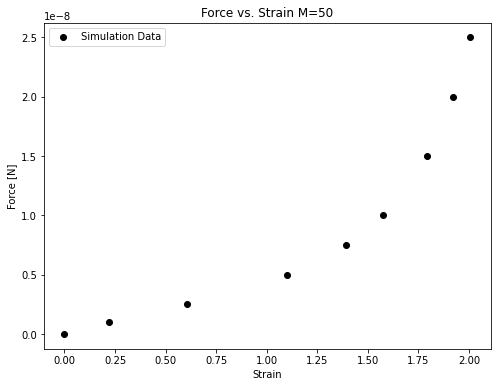

In [10]:
# For M = 50:
#Initial Tip Postion: z = 30 [lb units]
#Raw Format: [Position [lb Units], Force [lb Units], Force [N]]
M_50_Raw = np.array([
    [30,0,0],
    [34.4147,.0277,1e-9],
    [42.0683,.0694,2.5e-9],
    [51.9753,.1388,5e-9],
    [57.8265,.2083,7.5e-9],
    [61.4908,.2777,10e-9],
    [65.8536,.4166,15e-9],
    [68.4158,.5555,20e-9],
    [70.1381,.6944,25e-9],
]);

M_50_Strain = M_50_Raw;
for i in range(0,np.size(M_50_Raw[:,0]),1):
    M_50_Strain[i,0] = (M_50_Raw[i,0]-l0_LB-LB_Offset)/l0_LB;
    print(M_50_Strain[i,0])

force_strain,ax = plt.subplots(1,1,figsize=(8,6))                          #plot the curve and the experimental data
plt.title("Force vs. Strain M=50")
ax.set_xlabel("Strain")
ax.set_ylabel("Force [N]")
plt.scatter(M_50_Strain[:,0],M_50_Strain[:,2],color = 'black',label = 'Simulation Data')
#plt.plot(Len_Data[:,0], f_l_Pow(Len_Data[:,0],alpha_Pow[0]*1e-9,alpha_Pow[1]*1e-9,alpha_Pow[2]*1e-27),label='SciPy Fit') #Correct the magnitudes of the parameters
ax.legend()
plt.show()